In [40]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

**See first:** [Kalman filter](./2_kalman_basic.ipynb)

## Position estimation with KF

The initial position, $x_0$, of a vehicle is inexactly known: $x_0 \sim \mathcal{N}(0, 1000).$ The velocity of the vehicle, $u_t$, is approximately $10$ m/s in the following sense $u_t \sim \mathcal{N}(10, 8).$

The position of the vehicle can be measured (e.g., using GPS) every $h=0.05$s using a sensor with additive noise $v_t\sim\mathcal{N}(0, 15)$.

The dynamics of the position of the vehicle is
$$\begin{align*}
        x_{t+1} {}={} & x_t + hu_t,
        \\
        y_t {}={}     & x_t + v_t.
\end{align*}$$
**However:** $u_t$ is *not* a zero-mean random variable!

The velocity can be written as
$$u_t = \bar{u}_t + w_t,$$
where $\bar{u}_t = 10$m/s and $w_t \sim \mathcal{N}(0, 8)$. Since $\bar{u}_t$ is constant, $\bar{u}_{t+1} = \bar{u}_t$, so
$$\underbrace{\begin{bmatrix}
            x_{t+1} \\ \bar{u}_{t+1}
        \end{bmatrix}}_{z_{t+1}}
        {}={}
        \underbrace{
            \begin{bmatrix}
                1 & h
                \\
                0 & 1
            \end{bmatrix}
        }_{A}
        \cdot
        \underbrace{
            \begin{bmatrix}
                x_{t} \\ \bar{u}_{t}
            \end{bmatrix}
        }_{z_t}
        +
        \underbrace{
            \begin{bmatrix}
                h \\0
            \end{bmatrix}
        }_{G}
        w_t.$$
The state of the system is $z_t = (x_t, \bar{u}_t)$ with
$$z_0 \sim \mathcal{N}\left(\begin{bmatrix}0\\10\end{bmatrix},\begin{bmatrix}1000 & 0\\0 & 0\end{bmatrix}\right).$$
The output of the system is
$$y_t = \begin{bmatrix}1 & 0\end{bmatrix}z_t + v_t.$$

In [41]:
# Problem data
h = 0.05
A = np.array([[1, h],
              [0, 1]])
G = np.array([[h],
              [0]])
C = np.array([[1, 0]])
P0 = np.array([[1000, 0],
               [0, 0]])
x0_tilde = np.array([[0], [10]])
Q = 60
R = 15

Let us now introduce the measurement update and time update functions

In [42]:
# Measurement and Time update functions
def measurement_update(sigma_tu, x_tu, y):
    z = C @ sigma_tu @ C.T + R # auxiliary variable
    x_mu = x_tu + sigma_tu @ C.T @ np.linalg.solve(z, y - C@x_tu)
    sigma_mu = sigma_tu - sigma_tu @ C.T @ np.linalg.solve(z, C@sigma_tu)
    return sigma_mu, x_mu

def time_update(sigma_mu, x_mu):
    x_tu = A @ x_mu
    sigma_tu = A @ sigma_mu @ A.T + Q * (G @ G.T)
    return sigma_tu, x_tu

We can now perform simulations with the Kalman Filter

In [43]:
# Implementation of KF
x = np.random.multivariate_normal(x0_tilde.flatten(), P0, 1).reshape((-1,1)) # random initial state
sigma_tu, x_tu = P0, x0_tilde.reshape((-1, 1)) # initialisation

n_sim = 20
x_cache = np.zeros((n_sim, 2))
x_mu_cache = np.zeros((n_sim-1, 2))
x_cache[0, :] = x.T
for t in range(n_sim - 1):
    v = np.random.normal(0, np.sqrt(R), 1)
    y = C @ x + v
    sigma_mu, x_mu = measurement_update(sigma_tu, x_tu, y)
    x_mu_cache[t, :] = x_mu.T
    sigma_tu, x_tu = time_update(sigma_mu, x_mu)
    w = np.random.normal(0, np.sqrt(Q), 1).T
    x = A @ x + G * w
    x_cache[t+1, :] = x.T

and plot the results

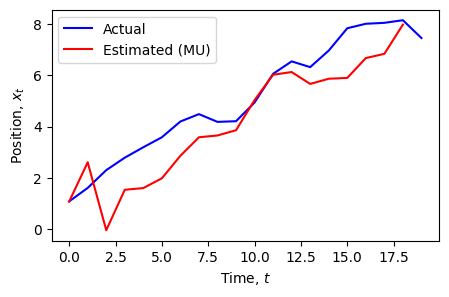

In [44]:
plt.figure(figsize=(5, 3))
plt.plot(np.arange(n_sim), x_cache[:, 0], 'b-', label='Actual')
plt.plot(np.arange(n_sim-1), x_mu_cache[:, 0], 'r-', label='Estimated (MU)')
plt.xlabel('Time, $t$')
plt.ylabel('Position, $x_t$')
plt.legend()
plt.show()

## Exercises


**Exercise 1.** Plot the actual position, $x_t$, against time. In the same axes, plot $\hat{x}_{t\mid t}$ and the $\pm 3\sigma$ intervals around it.

Use [`matplotlib.pyplot.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html).

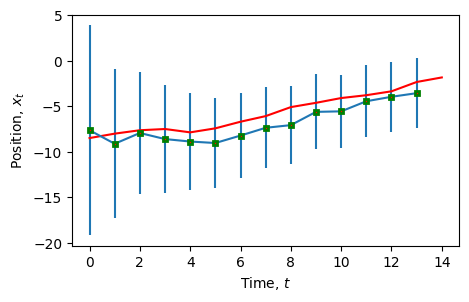

In [45]:
# Firstly, we need to repeat the simulations and cache the (cond.)
# variance of x_t given y_t, that is, Σtt...
n_sim = 15
x = np.random.multivariate_normal(x0_tilde.flatten(), P0, 1).reshape((-1,1)) # random initial state
sigma_tu, x_tu = P0, x0_tilde.reshape((-1, 1)) # initialisation
x_cache = np.zeros((n_sim, 2))
x_mu_cache = np.zeros((n_sim-1, 2))
sigma_mu_cache = np.zeros((n_sim-1, ))
x_cache[0, :] = x.T
for t in range(n_sim - 1):
    v = np.random.normal(0, np.sqrt(R), 1)
    y = C @ x + v
    sigma_mu, x_mu = measurement_update(sigma_tu, x_tu, y)
    x_mu_cache[t, :] = x_mu.T
    sigma_mu_cache[t] = sigma_mu[0, 0]
    sigma_tu, x_tu = time_update(sigma_mu, x_mu)
    w = np.random.normal(0, np.sqrt(Q), 1).T
    x = A @ x + G * w
    x_cache[t+1, :] = x.T

## Next, we use plt.errorbar to plot the
plt.figure(figsize=(5, 3))
plt.errorbar(np.arange(n_sim-1), x_mu_cache[:n_sim, 0], 3*np.sqrt(sigma_mu_cache),
             marker='s', mfc='red', mec='green', ms=3, mew=2)
plt.plot(np.arange(n_sim), x_cache[:, 0], 'r-', label='Actual')
plt.xlabel('Time, $t$')
plt.ylabel('Position, $x_t$')
plt.show()

**Exercise 2:** Suppose that the GPS connection is lost from time for a period of 1 second. Perform simulations with the KF. While there are no measurements use the time update only.

**Problem statement:** Suppose we do not have measurements from $t=T_1$ until (incl.) $t = T_2$.

**Implementation:**
- At time $t=T_1-1$ we receive the last measurement before the outage. We determine $\hat{x}_{T_1-1 \mid T_1 - 1}$ and $\Sigma_{T_1-1 \mid T_1 - 1}$
- We predict $\hat{x}_{T_1 \mid T_1 - 1}$ and $\Sigma_{T_1 \mid T_1 - 1}$
- At time $T_1$ we don't have measurements, so we can't determine $\hat{x}_{T_1 \mid T_1}$ and $\Sigma_{T_1 \mid T_1}$; the predicted estimates $\hat{x}_{T_1 \mid T_1 - 1}$ and $\Sigma_{T_1 \mid T_1 - 1}$ are our best estimates at time $T_1$
- We predict $\hat{x}_{T_1 + 1\mid T_1 - 1}$ by applying a time update


Outgage from T1 = 10 to T2 = 70


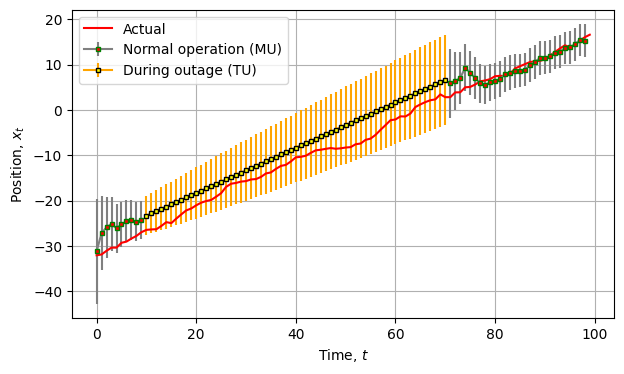

In [46]:
n_sim = 100
outage_duration_sec = 3
outage_start = 10
outage_end = outage_start + int(outage_duration_sec/h)
print(f"Outgage from T1 = {outage_start} to T2 = {outage_end}")

x = np.random.multivariate_normal(x0_tilde.flatten(), P0, 1).reshape((-1,1)) # random initial state
sigma_tu, x_tu = P0, x0_tilde.reshape((-1, 1)) # initialisation
x_cache = np.zeros((n_sim, 2))
x_mu_cache = np.zeros((n_sim-1, 2))
x_tu_cache = np.zeros((n_sim, 2))
sigma_mu_cache = np.zeros((n_sim-1, ))
sigma_tu_cache = np.zeros((n_sim, ))
sigma_tu_cache[0] = P0[0, 0]
x_tu_cache[0] = x_tu.T
x_cache[0, :] = x.T
for t in range(n_sim - 1):
    v = np.random.normal(0, np.sqrt(R), 1)
    y = C @ x + v

    # prior at time t is already in (x_tu, sigma_tu)
    if outage_start <= t <= outage_end:
        # no measurement: posterior = prior
        x_mu, sigma_mu = x_tu, sigma_tu
    else:
        sigma_mu, x_mu = measurement_update(sigma_tu, x_tu, y)

    # store filtered estimate at time t
    x_mu_cache[t, :] = x_mu.T
    sigma_mu_cache[t] = sigma_mu[0, 0]

    # predict for time t+1
    sigma_tu, x_tu = time_update(sigma_mu, x_mu)
    x_tu_cache[t+1, :] = x_tu.T
    sigma_tu_cache[t+1] = sigma_tu[0, 0]

    # propagate true system
    w = np.random.normal(0, np.sqrt(Q), 1)
    x = A @ x + G * w
    x_cache[t+1, :] = x.T

# Plot...
plt.figure(figsize=(7, 4))
# BEFORE
plt.errorbar(np.arange(outage_start),
             x_mu_cache[:outage_start, 0],
             3*np.sqrt(sigma_mu_cache[:outage_start]),
             color='gray', marker='s', mfc='red', mec='green', ms=3, mew=1,
             label='Normal operation (MU)')
# DURING
plt.errorbar(outage_start+np.arange(outage_end-outage_start+1),
             x_tu_cache[outage_start+1:outage_end+2, 0],
             3*np.sqrt(sigma_tu_cache[outage_start:outage_end+1]),
             color='orange', marker='s', mfc='yellow', mec='black', ms=3, mew=1,
             label='During outage (TU)')
# AFTER
plt.errorbar(outage_end + 1 + np.arange(n_sim-outage_end-2),
             x_mu_cache[outage_end+1:, 0],
             3*np.sqrt(sigma_mu_cache[outage_end+1:]),
             color='gray', marker='s', mfc='red', mec='green', ms=3, mew=1)

plt.plot(np.arange(n_sim), x_cache[:, 0], 'r-', label='Actual')
plt.xlabel('Time, $t$')
plt.ylabel('Position, $x_t$')
plt.legend()
plt.grid()
plt.show()

**See next:** [Variants of the Kalman filter](./4_kalman_variants.ipynb)